# A first linear model: what explains the wait to be seen?

**Master in Healthcare Analytics · Session: Linear models I (first part)**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

Earlier sessions described the wait to see a provider one factor at a time: it rises with crowding, it jumps in the afternoon, it depends on acuity. A **linear model** puts several factors into one equation and estimates how much each contributes *while holding the others fixed*. This session builds the simplest version of that model, learns to read it, and draws it on top of the data so that the numbers in the table have a shape.

**Plan.**

1. The question, the response and three continuous predictors.
2. The model as an equation, and fitting it with statsmodels.
3. Reading the coefficient table in clinical units, and seeing the fitted model on the data.

How good the model is (R², residuals and diagnostics) and how to improve it are left for the next part. Categorical predictors (acuity, treatment area) come after that.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})
pd.set_option("display.width", 160)

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)
print(visits.shape)

(44861, 31)


## 1. The question, the response and the predictors

**Question.** How long does a patient wait between arriving and first seeing a provider, and what makes that wait longer or shorter?

**Response.** `door_to_provider_min`, in minutes. Only visits with a provider contact can be used, so the 872 LWBS visits are excluded, and we say so.

**Predictors.** Three continuous variables, each chosen to teach something:

- `ed_census_at_arrival` — how many patients were in the department when this one arrived. The crowding variable.
- `arrival_hour` — the hour of arrival (0–23). Earlier sessions showed that waits change through the day.
- `n_labs` — the number of laboratory tests ordered. Not obviously related to waiting; included so that we can see what a model does with a variable whose effect is *indirect*.

Before fitting anything, look at the response and at each predictor against it. A model should never be the first thing you do.

Visits used: 43,989   wait: median 37 min, mean 46.3, P90 88, max 574


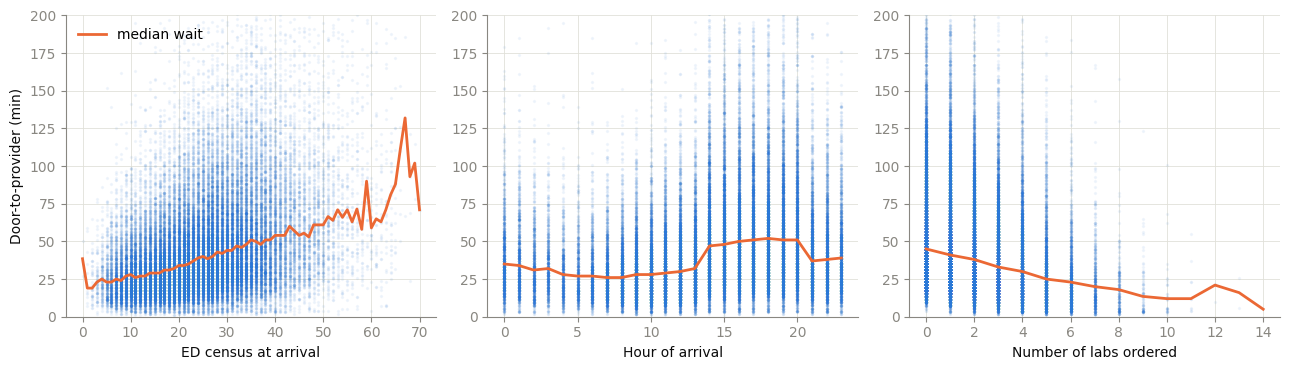

In [2]:
seen = visits[visits["provider_datetime"].notna()].copy()
y = seen["door_to_provider_min"]
print(f"Visits used: {len(seen):,}   wait: median {y.median():.0f} min, mean {y.mean():.1f}, P90 {y.quantile(0.9):.0f}, max {y.max():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, lab in zip(axes, ["ed_census_at_arrival", "arrival_hour", "n_labs"], ["ED census at arrival", "Hour of arrival", "Number of labs ordered"]):
    g = seen.groupby(col)["door_to_provider_min"].median()
    ax.scatter(seen[col], seen["door_to_provider_min"], s=2, alpha=0.05, color=BLUE)
    ax.plot(g.index, g.values, color=ORANGE, linewidth=2, label="median wait")
    ax.set_xlabel(lab); ax.set_ylim(0, 200)
axes[0].set_ylabel("Door-to-provider (min)"); axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

Three different shapes. Against census, the median wait rises steadily and roughly in a straight line. Against hour, it is flat in the morning and steps up in the afternoon: not a straight line. Against labs, it *falls*: patients with more tests are seen sooner, which seems backwards until you remember that sicker patients get both more tests and faster attention. Keep all three observations; the model will have to answer to them.

## 2. The model as an equation

A linear model with three predictors says that the expected wait is a weighted sum:

$$\text{wait} = \beta_0 + \beta_1 \cdot \text{census} + \beta_2 \cdot \text{hour} + \beta_3 \cdot \text{labs} + \varepsilon$$

- $\beta_0$ is the **intercept**: the expected wait when every predictor is zero (an empty department at midnight with no labs; not a real situation, just where the line starts).
- Each $\beta$ is a **slope**: how much the expected wait changes when that predictor increases by one unit *and the others stay the same*. That last clause is what makes a model different from three separate plots.
- $\varepsilon$ is everything the model does not capture: the residual.

Fitting the model means finding the $\beta$ values that make the residuals as small as possible overall (ordinary least squares). statsmodels does this from a formula that reads almost like the equation.

In [3]:
model_1 = smf.ols("door_to_provider_min ~ ed_census_at_arrival + arrival_hour + n_labs", data=seen).fit()
print(model_1.summary().tables[1])

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               25.2662      0.440     57.456      0.000      24.404      26.128
ed_census_at_arrival     1.0281      0.016     63.144      0.000       0.996       1.060
arrival_hour             0.2141      0.031      6.898      0.000       0.153       0.275
n_labs                  -4.1535      0.082    -50.565      0.000      -4.315      -3.993


## 3. Reading the coefficient table

Each row is one term of the equation. The columns that matter:

- **coef** — the estimated $\beta$. In the units of the response per unit of the predictor: minutes per patient in the department, minutes per hour of the clock, minutes per lab test.
- **std err** — how uncertain that estimate is; with 44,000 visits, small.
- **[0.025, 0.975]** — the 95% confidence interval: the range of values compatible with the data.
- **P>|t|** — the p-value for "the true coefficient is zero". Here every predictor is far below 0.05, which is unsurprising with this much data; the *size* of the effect matters more than the p-value.

Read the numbers in clinical language.

In [4]:
b = model_1.params
print(f"Each additional patient in the department when you arrive adds about {b['ed_census_at_arrival']:.2f} minutes to the expected wait.")
print(f"Each hour later in the day adds about {b['arrival_hour']:.2f} minutes (on average across the day; the plot below shows why this is misleading).")
print(f"Each additional lab test is associated with {abs(b['n_labs']):.1f} minutes LESS waiting.")
print()
print("Example: a patient arriving at 15:00 with 30 people in the department and 2 labs ordered.")
example = pd.DataFrame({"ed_census_at_arrival": [30], "arrival_hour": [15], "n_labs": [2]})
print(f"Predicted wait: {model_1.predict(example).iloc[0]:.0f} minutes")

Each additional patient in the department when you arrive adds about 1.03 minutes to the expected wait.
Each hour later in the day adds about 0.21 minutes (on average across the day; the plot below shows why this is misleading).
Each additional lab test is associated with 4.2 minutes LESS waiting.

Example: a patient arriving at 15:00 with 30 people in the department and 2 labs ordered.
Predicted wait: 51 minutes


The census effect is the useful one: about a minute per patient, so a department with 40 patients waits roughly 20 minutes longer than one with 20. The labs effect is real in the data but is not what it looks like. It is not that ordering tests speeds things up; it is that `n_labs` is standing in for something the model cannot see (acuity). A coefficient describes an association *given the other variables in the model*, and nothing more. We will return to this in the next session.

### Seeing the model on the data

A table of coefficients is abstract. The easiest way to understand what the model has done is to draw it on top of the data.

With three predictors the model is a flat surface in four dimensions, which nobody can draw. What we *can* draw is one slice at a time. Take the example patient above (arrives at 15:00, 30 patients in the department, 2 labs ordered). Keep two of those values fixed and let the third one vary. The equation then becomes a **straight line**, and the slope of that line is exactly the coefficient of the predictor that varies:

- Left panel: hour fixed at 15, labs fixed at 2, census varies → slope = $\beta_1$.
- Middle panel: census fixed at 30, labs fixed at 2, hour varies → slope = $\beta_2$.
- Right panel: census fixed at 30, hour fixed at 15, labs vary → slope = $\beta_3$.

The example patient (the star) sits on all three lines, because all three are slices through the same point of the same equation. The grey dots show the observed median wait for each value of the predictor, so you can judge whether a straight line is a fair description. Hour and labs are whole numbers, so their points are spread sideways a little (jitter) to make the cloud visible.

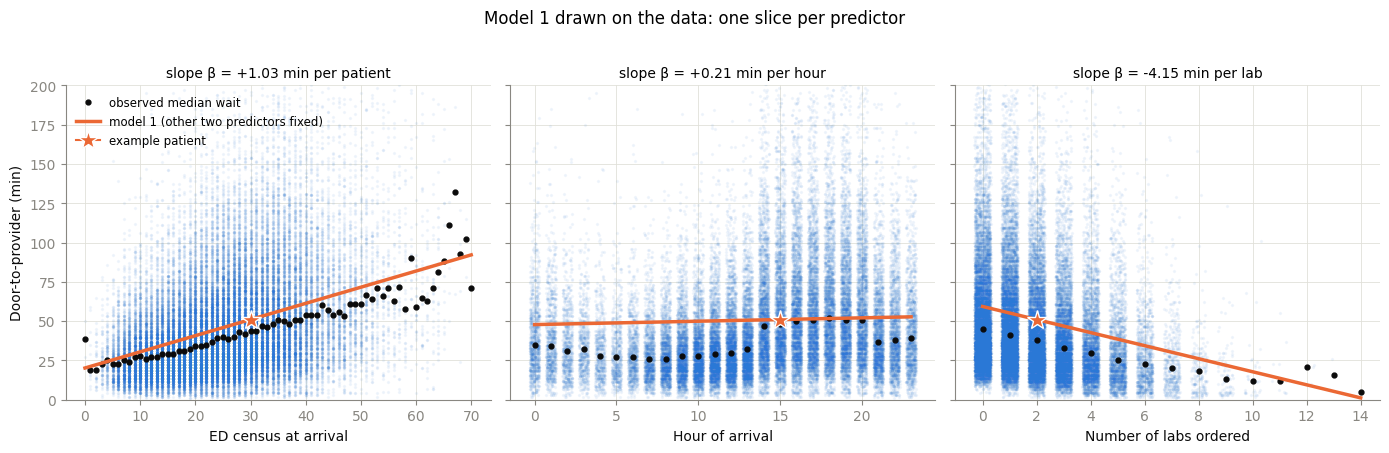

Example patient (15:00, census 30, 2 labs): predicted wait 51 min


In [5]:
ex = {"ed_census_at_arrival": 30, "arrival_hour": 15, "n_labs": 2}
ex_pred = model_1.predict(pd.DataFrame([ex])).iloc[0]
panels = [("ed_census_at_arrival", "ED census at arrival", "min per patient", 0.0),
          ("arrival_hour", "Hour of arrival", "min per hour", 0.3),
          ("n_labs", "Number of labs ordered", "min per lab", 0.3)]
rng = np.random.default_rng(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (col, lab, unit, jit) in zip(axes, panels):
    x = seen[col] + (rng.uniform(-jit, jit, len(seen)) if jit else 0)
    ax.scatter(x, seen["door_to_provider_min"], s=2, alpha=0.05, color=BLUE, rasterized=True)
    med = seen.groupby(col)["door_to_provider_min"].median()
    ax.plot(med.index, med.values, "o", color=INK, markersize=3.5, label="observed median wait")
    # the model line: this predictor varies, the other two stay at the example patient's values
    grid = pd.DataFrame({k: v for k, v in ex.items() if k != col}, index=range(100))
    grid[col] = np.linspace(seen[col].min(), seen[col].max(), 100)
    ax.plot(grid[col], model_1.predict(grid), color=ORANGE, linewidth=2.5, label="model 1 (other two predictors fixed)")
    ax.plot(ex[col], ex_pred, marker="*", markersize=15, color=ORANGE, markeredgecolor="white", zorder=5, label="example patient")
    ax.set_xlabel(lab); ax.set_ylim(0, 200)
    ax.set_title(f"slope β = {model_1.params[col]:+.2f} {unit}", fontsize=10)
axes[0].set_ylabel("Door-to-provider (min)")
axes[0].legend(frameon=False, loc="upper left", fontsize=8.5)
fig.suptitle("Model 1 drawn on the data: one slice per predictor", y=1.02)
plt.tight_layout(); plt.show()
print(f"Example patient (15:00, census 30, 2 labs): predicted wait {ex_pred:.0f} min")

Read the three panels one at a time.

**Census (left).** The line climbs at about one minute per patient, at the same rate as the observed medians. It sits a little above them because this slice is for a 15:00 arrival, a busier-than-average hour. A straight line is a fair summary of how crowding affects the wait.

**Hour (middle).** A straight line cannot follow what the medians do. They are flat through the morning, jump at 14:00 and fall back at 21:00, while the line rises by only 0.2 minutes per hour all day. A single slope cannot represent a step, so it averages the step into a gentle rise. That is why the hour coefficient is misleading.

**Labs (right).** The line slopes *down*, like the medians. More labs, shorter wait. The model has faithfully reproduced an association, but the association is driven by acuity: sicker patients get more tests and are seen sooner.

Two more things to notice in every panel.

- **The line is the expected wait, not the wait.** Individual patients scatter far above and below it. The vertical distance from a dot to the line is that patient's residual, the $\varepsilon$ in the equation. The cloud is wide, and it is wider above the line than below, because waits cannot fall below zero but can be very long. The next part measures how much of the variation the line explains.
- **"Holding the others fixed" has a picture.** Give the example patient 5 labs instead of 2 and the census line drops by about 12 minutes (3 × 4.15), but its slope stays exactly the same. In this model each predictor adds its own fixed amount, whatever the values of the others.